# **Ensemble Learning: homework**

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

## **Dataset**

In [3]:
!wget -P ./ensemble_learning/data/ https://github.com/alexeygrigorev/datasets/raw/refs/heads/master/jamb_exam_results.csv

--2024-11-04 16:51:18--  https://github.com/alexeygrigorev/datasets/raw/refs/heads/master/jamb_exam_results.csv
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/alexeygrigorev/datasets/refs/heads/master/jamb_exam_results.csv [following]
--2024-11-04 16:51:18--  https://raw.githubusercontent.com/alexeygrigorev/datasets/refs/heads/master/jamb_exam_results.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 391501 (382K) [text/plain]
Saving to: ‘./ensemble_learning/data/jamb_exam_results.csv’

jamb_exam_results.c 100%[===================>] 382.33K  1.33MB/s    in 0.3s    

2024-11-04 16:51:19 (1.33 

In [3]:
df = pd.read_csv("./ensemble_learning/data/jamb_exam_results.csv")
df.sample(5)

,JAMB_Score,Study_Hours_Per_Week,Attendance_Rate,Teacher_Quality,Distance_To_School,School_Type,School_Location,Extra_Tutorials,Access_To_Learning_Materials,Parent_Involvement,IT_Knowledge,Student_ID,Age,Gender,Socioeconomic_Status,Parent_Education_Level,Assignments_Completed
2980,195,25,95,2,12.0,Private,Rural,Yes,Yes,Low,Low,2981,19,Male,Low,Secondary,1
2564,178,4,84,3,7.4,Private,Urban,No,No,Medium,Medium,2565,17,Female,Medium,Secondary,1
18,238,14,100,3,4.1,Public,Rural,No,Yes,High,High,19,20,Female,High,Secondary,1
1615,198,4,66,4,14.4,Public,Rural,No,Yes,Medium,High,1616,15,Male,Medium,Primary,1
2231,152,19,77,2,9.4,Public,Rural,No,No,Medium,Low,2232,15,Male,Low,Tertiary,1


In [4]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [5]:
df.sample(5)

,jamb_score,study_hours_per_week,attendance_rate,teacher_quality,distance_to_school,school_type,school_location,extra_tutorials,access_to_learning_materials,parent_involvement,it_knowledge,student_id,age,gender,socioeconomic_status,parent_education_level,assignments_completed
2213,235,30,81,4,1.3,Public,Urban,Yes,Yes,Medium,Medium,2214,15,Male,Medium,Tertiary,3
2074,160,0,77,3,11.1,Public,Urban,No,No,Low,Low,2075,20,Female,Medium,Tertiary,1
3450,183,15,82,2,4.2,Private,Urban,Yes,Yes,Low,High,3451,15,Male,Medium,Primary,2
4014,293,30,82,2,7.7,Public,Urban,Yes,No,High,High,4015,17,Female,Medium,Secondary,2
109,141,33,81,2,17.1,Public,Urban,Yes,No,Low,High,110,22,Female,Medium,NaN,4


In [6]:
del df['student_id']

In [7]:
df.fillna(0, inplace=True)

splitting the dataset into train/validation/test with 60%/20%/20% distribution

In [8]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [9]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [10]:
y_train = df_train['jamb_score'].values
y_val = df_val['jamb_score'].values
y_test = df_test['jamb_score'].values

In [11]:
del df_train['jamb_score']
del df_val['jamb_score']
del df_test['jamb_score']

Use DictVectorizer(sparse=True) to turn the dataframes into matrices

In [12]:
from sklearn.feature_extraction import DictVectorizer

In [13]:
train_dicts = df_train.to_dict(orient='records')
val_dicts = df_val.to_dict(orient='records')
tests_dicts = df_test.to_dict(orient='records')

In [14]:
dv = DictVectorizer(sparse=True)
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)
X_test = dv.transform(tests_dicts)

In [15]:
dv.get_feature_names_out()

array(['access_to_learning_materials=No',
       'access_to_learning_materials=Yes', 'age', 'assignments_completed',
       'attendance_rate', 'distance_to_school', 'extra_tutorials=No',
       'extra_tutorials=Yes', 'gender=Female', 'gender=Male',
       'it_knowledge=High', 'it_knowledge=Low', 'it_knowledge=Medium',
       'parent_education_level', 'parent_education_level=Primary',
       'parent_education_level=Secondary',
       'parent_education_level=Tertiary', 'parent_involvement=High',
       'parent_involvement=Low', 'parent_involvement=Medium',
       'school_location=Rural', 'school_location=Urban',
       'school_type=Private', 'school_type=Public',
       'socioeconomic_status=High', 'socioeconomic_status=Low',
       'socioeconomic_status=Medium', 'study_hours_per_week',
       'teacher_quality'], dtype=object)

## **Baseline model:**

Train a decision tree regressor to predict the jamb_score variable

In [16]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_text

In [17]:
baseline_tree = DecisionTreeRegressor(max_depth=1)

In [18]:
baseline_tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=1)

In [19]:
print(export_text(baseline_tree, feature_names=dv.get_feature_names_out().tolist()))

|--- study_hours_per_week <= 18.50
|   |--- value: [155.24]
|--- study_hours_per_week >  18.50
|   |--- value: [188.59]



Train a random forest regressor

In [20]:
from sklearn.ensemble import RandomForestRegressor

In [21]:
baseline_random_fr = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)

In [22]:
baseline_random_fr.fit(X_train, y_train)

RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=1)

In [23]:
y_preds_rfr = baseline_random_fr.predict(X_val)

In [24]:
from sklearn.metrics import root_mean_squared_error

ImportError: cannot import name 'root_mean_squared_error' from 'sklearn.metrics' (/mnt/c/Users/Javier/Documents/ml_zoomcamp_2024/env/lib/python3.10/site-packages/sklearn/metrics/__init__.py)

In [34]:
def root_mean_square_error(y_val, y_preds):
    return np.sqrt(np.mean((y_val - y_preds)**2)).round(3)

In [35]:
rmse_base_rfr = root_mean_square_error(y_val, y_preds_rfr)
rmse_base_rfr

42.137

## **Now let's experiment with the n_estimators parameter**

In [26]:
n_estimators = range(10, 201, 10)

In [ ]:
rmse_scores = []
for n in n_estimators:
    mdl = RandomForestRegressor(n_estimators=n, random_state=1)
    mdl.fit(X_train, y_train)
    y_preds = mdl.predict(X_val)
    rmse_score = root_mean_square_error(y_val, y_preds)
    rmse_scores.append((n, rmse_score))

In [37]:
df_scores = pd.DataFrame(rmse_scores, columns=['n_estimators', 'RMSE'])

In [38]:
df_scores.sort_values(by='RMSE', ascending=True)

,n_estimators,RMSE
8,90,40.504
9,100,40.517
7,80,40.539
10,110,40.593
13,140,40.595
14,150,40.597
19,200,40.601
15,160,40.604
11,120,40.625
16,170,40.628


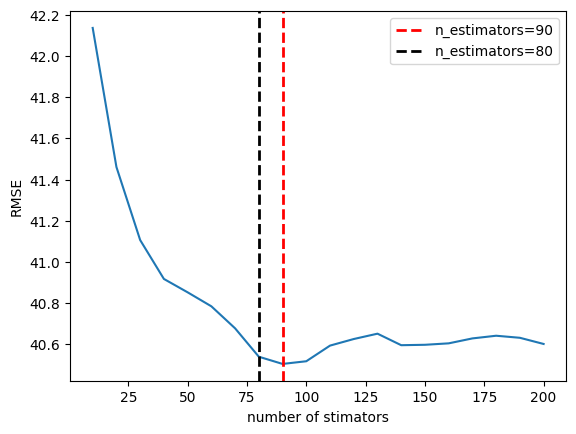

In [39]:
plt.plot(df_scores.n_estimators, df_scores.RMSE)
plt.axvline(x=90, color='r', linestyle='--', linewidth=2, label='n_estimators=90')
plt.axvline(x=80, color='k', linestyle='--', linewidth=2, label='n_estimators=80')
plt.xlabel("number of stimators")
plt.ylabel("RMSE")
plt.legend()

## **Search for the max_depth hyperparameter**

In [40]:
max_depth = range(10,26,5)

In [42]:
rmse_scores = []
for depth in max_depth:
    for n in n_estimators:
        mdl2 = RandomForestRegressor(n_estimators=n, max_depth=depth, random_state=1)
        mdl2.fit(X_train, y_train)
        y_preds = mdl2.predict(X_val)
        rmse_score = root_mean_square_error(y_val, y_preds)
        rmse_scores.append((depth, n, rmse_score))

In [43]:
df_scores2 = pd.DataFrame(rmse_scores, columns=['depth','n_estimators', 'RMSE'])
df_scores2.sort_values(by='RMSE')

,depth,n_estimators,RMSE
8,10,90,40.174
7,10,80,40.210
9,10,100,40.250
3,10,40,40.270
5,10,60,40.277
...,...,...,...
21,15,20,41.456
61,25,20,41.471
20,15,10,42.004
40,20,10,42.025


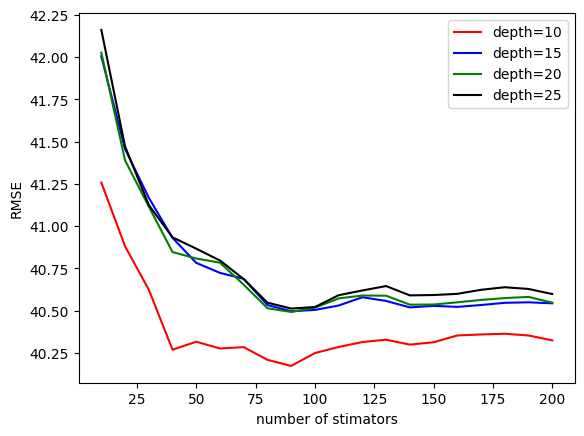

In [ ]:
colors = ['r', 'b', 'g', 'k']
depth_colors = zip(max_depth, colors)

for depth, color in depth_colors:
    df_filtered = df_scores2[df_scores2['depth'] == depth]
    plt.plot(df_filtered.n_estimators, df_filtered.RMSE, label=f"depth={depth}", color=color)
    plt.xlabel("number of stimators")
    plt.ylabel("RMSE")
    plt.legend()

## **Feature importance information:**

In [48]:
model_5 = RandomForestRegressor(n_estimators=10, max_depth=20, random_state=1,n_jobs=-1)

In [49]:
model_5.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=10, n_jobs=-1, random_state=1)

In [50]:
importances = model_5.feature_importances_
features_names = dv.get_feature_names_out()

In [51]:
importances_dict = dict(zip(features_names, importances))
sorted_importances = sorted(importances_dict.items(), key=lambda x: x[1], reverse=True)
for feature, importance in sorted_importances:
    print(f"{feature}: {importance}")

study_hours_per_week: 0.24835361199396536
attendance_rate: 0.1497290297846747
distance_to_school: 0.1364858048632369
teacher_quality: 0.0826822226388016
age: 0.06931145469695398
assignments_completed: 0.03151678945460071
socioeconomic_status=High: 0.025714264343587142
parent_involvement=High: 0.022918852929064194
it_knowledge=High: 0.0177193420394119
parent_education_level=Secondary: 0.016956919815100068
parent_education_level=Primary: 0.01545036018792814
parent_education_level=Tertiary: 0.014488617277194148
extra_tutorials=No: 0.013459336291731934
parent_involvement=Low: 0.013357613537934167
it_knowledge=Low: 0.012404050525957137
access_to_learning_materials=No: 0.012325395818561702
parent_involvement=Medium: 0.011492011642547156
socioeconomic_status=Low: 0.010707977461688629
socioeconomic_status=Medium: 0.010562682989822823
gender=Male: 0.010382634572648446
access_to_learning_materials=Yes: 0.010261891957053597
school_location=Rural: 0.009559093298481168
gender=Female: 0.009288710588

## **XGBoost model:**

In [52]:
import xgboost as xgb

/mnt/c/Users/Javier/Documents/ml_zoomcamp_2024/env/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [53]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [54]:
xgb_params_1 = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

xgb_model_eta1 = xgb.train(xgb_params_1, dtrain, num_boost_round=100)

In [55]:
y_preds_1 = xgb_model_eta1.predict(dval)
print(f"validaton RMSE for eta=0.3: {root_mean_square_error(y_val, y_preds_1)}")

validaton RMSE for eta=0.3: 43.419


In [56]:
xgb_params_2 = {
    'eta': 0.1, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

xgb_model_eta2 = xgb.train(xgb_params_2, dtrain, num_boost_round=100)

In [57]:
y_preds_2 = xgb_model_eta2.predict(dval)
print(f"validaton RMSE for eta=0.3: {root_mean_square_error(y_val, y_preds_2)}")

validaton RMSE for eta=0.3: 41.05
